# Demo 3b: Image Segmentation

Image segmentation classifies every pixel in an image. This demo covers:
1. Pretrained **DeepLabV3** from torchvision for general segmentation
2. **Oxford-IIIT Pet** trimap masks as real ground-truth segmentation data
3. **segmentation_models_pytorch** (smp) to create a U-Net for medical use

## Setup

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms, datasets
from torchvision.transforms.functional import to_tensor, to_pil_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 1: Pretrained DeepLabV3

torchvision provides pretrained segmentation models. DeepLabV3 with a
ResNet-50 backbone is trained on a subset of COCO for 21 classes
(background + 20 object categories including cats and dogs).

In [2]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# Load pretrained model
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model = model.to(device)
model.eval()

# Get preprocessing transforms
preprocess = weights.transforms()

# Class names
categories = weights.meta["categories"]
print(f"Segmentation classes ({len(categories)}): {categories}")

Segmentation classes (21): ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


## Run Segmentation on a Pet Photo

We'll use the Oxford-IIIT Pet dataset. DeepLabV3 knows about cats and dogs
(COCO classes 8 and 12), so it should segment them well.

In [3]:
# Load Oxford-IIIT Pet dataset (images only)
pet_dataset = datasets.OxfordIIITPet(root="./data", split="test", download=True)

# Pick a sample image
img, label = pet_dataset[0]
print(f"Image size: {img.size}")

# Preprocess and run inference
img_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)["out"]  # shape: (1, num_classes, H, W)

# Get per-pixel class predictions
predictions = output.argmax(dim=1).squeeze(0).cpu().numpy()
print(f"Output shape: {output.shape}")
print(f"Prediction map shape: {predictions.shape}")
unique_classes = np.unique(predictions)
print(f"Classes found: {[categories[c] for c in unique_classes]}")

Image size: (300, 225)


Output shape: torch.Size([1, 21, 520, 693])
Prediction map shape: (520, 693)
Classes found: ['__background__', 'cat', 'chair', 'diningtable']


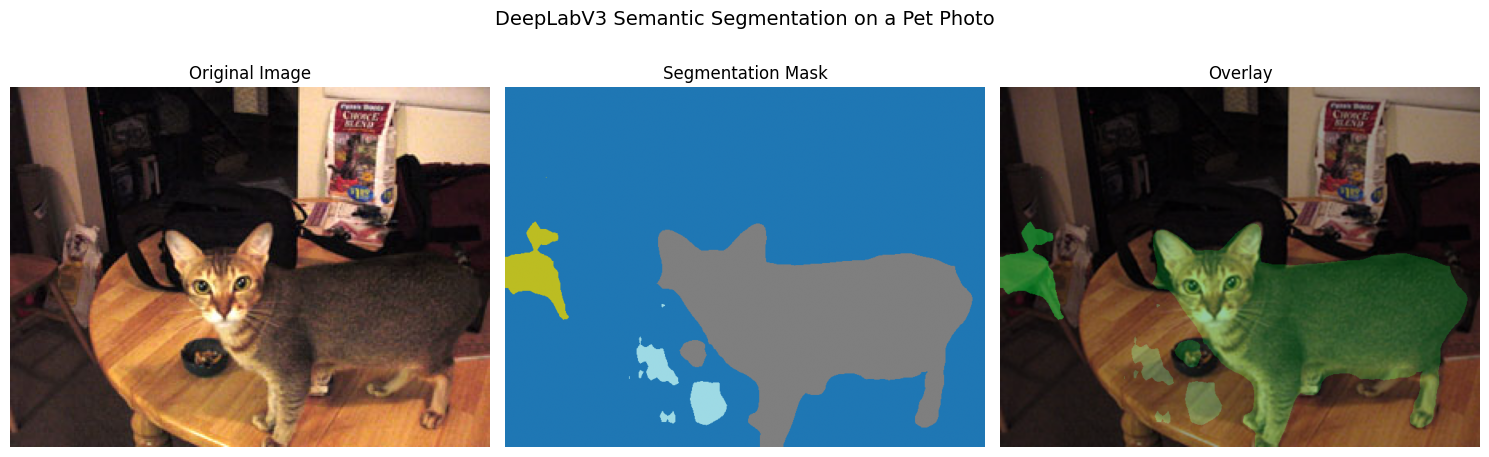

In [4]:
from torchvision.utils import draw_segmentation_masks

# Visualize original vs segmentation mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(predictions, cmap="tab20")
axes[1].set_title("Segmentation Mask")
axes[1].axis("off")

# Overlay using draw_segmentation_masks (counterpart to draw_bounding_boxes)
img_resized = img.resize(predictions.shape[::-1])
img_uint8 = (to_tensor(img_resized) * 255).byte()
pred_tensor = torch.tensor(predictions)
class_masks = pred_tensor.unsqueeze(0) == torch.arange(len(categories)).view(-1, 1, 1)
# Keep only classes that actually appear
present = class_masks.any(dim=-1).any(dim=-1)
overlay = draw_segmentation_masks(img_uint8, class_masks[present], alpha=0.4)
axes[2].imshow(to_pil_image(overlay))
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.suptitle("DeepLabV3 Semantic Segmentation on a Pet Photo", fontsize=14)
plt.tight_layout()
plt.show()

## Part 2: Real Segmentation Masks (Oxford-IIIT Pet Trimaps)

The Oxford-IIIT Pet dataset includes **trimap segmentation masks** for
every image — real, human-annotated pixel labels:
- **1** = foreground (the pet)
- **2** = background
- **3** = boundary/uncertain

In [5]:
# Load the dataset with segmentation masks
pet_seg = datasets.OxfordIIITPet(
    root="./data", split="test", download=True,
    target_types="segmentation",
)

# Get an image and its ground-truth mask
img, mask = pet_seg[0]
mask_array = np.array(mask)

print(f"Image size: {img.size}")
print(f"Mask shape: {mask_array.shape}")
print(f"Mask unique values: {np.unique(mask_array)}")
print(f"  1 = foreground (pet), 2 = background, 3 = boundary")

Image size: (300, 225)
Mask shape: (225, 300)
Mask unique values: [1 2 3]
  1 = foreground (pet), 2 = background, 3 = boundary


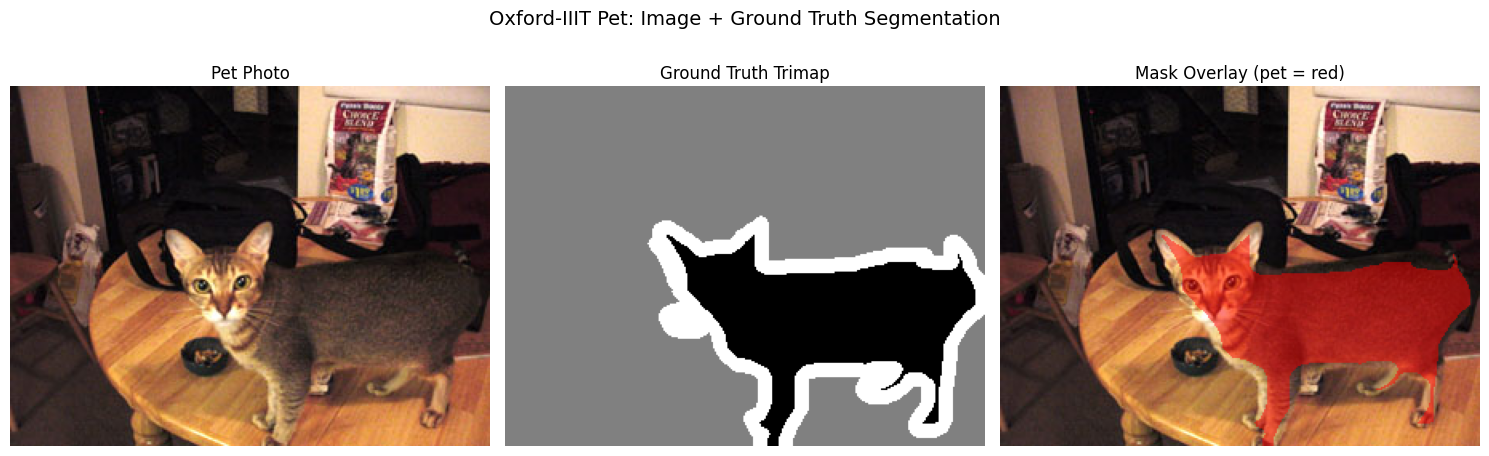

In [6]:
# Display image alongside its ground-truth segmentation mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Pet Photo")
axes[0].axis("off")

axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Ground Truth Trimap")
axes[1].axis("off")

# Overlay: highlight the pet in red using draw_segmentation_masks
img_resized_gt = img.resize(mask_array.shape[::-1])
img_uint8_gt = (to_tensor(img_resized_gt) * 255).byte()
pet_mask = torch.tensor(mask_array == 1).unsqueeze(0)  # (1, H, W) bool
overlay = draw_segmentation_masks(img_uint8_gt, pet_mask, alpha=0.5, colors=["red"])
axes[2].imshow(to_pil_image(overlay))
axes[2].set_title("Mask Overlay (pet = red)")
axes[2].axis("off")

plt.suptitle("Oxford-IIIT Pet: Image + Ground Truth Segmentation", fontsize=14)
plt.tight_layout()
plt.show()

## Part 3: Computing Dice Score

The **Dice coefficient** measures overlap between predicted and ground truth
masks. It ranges from 0 (no overlap) to 1 (perfect match).
`torchmetrics.segmentation.DiceScore` handles batching and multi-class cases.

In [7]:
from torchmetrics.segmentation import DiceScore
from torch.nn.functional import interpolate

# Compare DeepLabV3 prediction with the ground truth
# DeepLabV3 classes: cat=8, dog=12. Extract the predicted animal mask.
cat_idx = categories.index("cat")
dog_idx = categories.index("dog")

# Get the predicted probability for cat or dog (whichever is higher)
probs = torch.softmax(output, dim=1).squeeze(0).cpu()
animal_pred = torch.max(probs[cat_idx], probs[dog_idx])

# Ground truth: convert trimap to binary (1=pet, 0=everything else)
gt_binary = torch.tensor((mask_array == 1).astype(np.float32))

# Resize prediction to match ground truth
animal_pred_resized = interpolate(
    animal_pred.unsqueeze(0).unsqueeze(0),
    size=gt_binary.shape,
    mode="bilinear",
    align_corners=False,
).squeeze()

# Convert to index format for DiceScore: (N, H, W) with integer class labels
pred_idx = (animal_pred_resized > 0.5).long().unsqueeze(0)  # (1, H, W)
gt_idx = gt_binary.long().unsqueeze(0)                       # (1, H, W)

# Compute Dice with torchmetrics
dice_metric = DiceScore(num_classes=2, input_format="index")
score = dice_metric(pred_idx, gt_idx)
print(f"Dice Score (DeepLabV3 vs ground truth): {score:.4f}")

# A perfect prediction scores 1.0
dice_metric.reset()
perfect = dice_metric(gt_idx, gt_idx)
print(f"Perfect Dice Score: {perfect:.4f}")

Dice Score (DeepLabV3 vs ground truth): 0.9389
Perfect Dice Score: 1.0000


/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


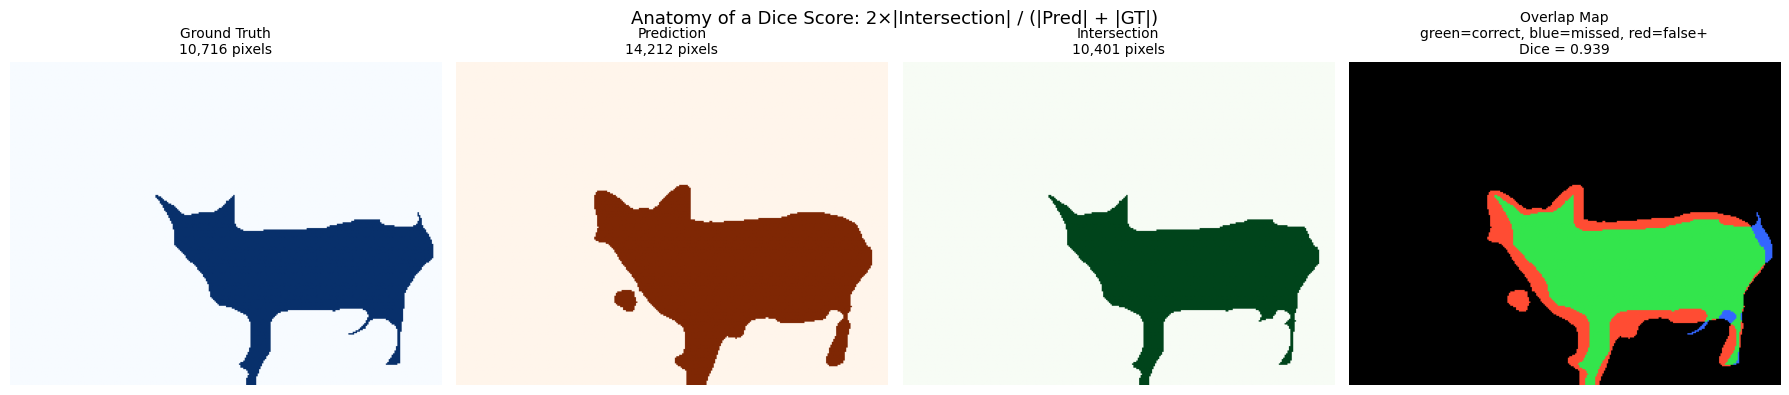

In [8]:
# Visualize what Dice score actually measures:
# Dice = 2×|Intersection| / (|Pred| + |GT|)
pred_binary = (animal_pred_resized > 0.5).numpy()
gt_np = gt_binary.numpy().astype(bool)
intersection = pred_binary & gt_np

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(gt_np, cmap="Blues")
axes[0].set_title(f"Ground Truth\n{gt_np.sum():,} pixels", fontsize=10)
axes[0].axis("off")

axes[1].imshow(pred_binary, cmap="Oranges")
axes[1].set_title(f"Prediction\n{pred_binary.sum():,} pixels", fontsize=10)
axes[1].axis("off")

axes[2].imshow(intersection, cmap="Greens")
axes[2].set_title(f"Intersection\n{intersection.sum():,} pixels", fontsize=10)
axes[2].axis("off")

# Composite: blue=GT only, red=pred only, green=overlap
composite = np.zeros((*gt_np.shape, 3))
composite[gt_np & ~pred_binary] = [0.2, 0.4, 1.0]       # blue: missed by model
composite[pred_binary & ~gt_np] = [1.0, 0.3, 0.2]       # red: false positive
composite[intersection] = [0.2, 0.9, 0.3]                # green: correct overlap
axes[3].imshow(composite)
axes[3].set_title(f"Overlap Map\ngreen=correct, blue=missed, red=false+\n"
                  f"Dice = {score:.3f}", fontsize=10)
axes[3].axis("off")

plt.suptitle("Anatomy of a Dice Score: 2×|Intersection| / (|Pred| + |GT|)", fontsize=13)
plt.tight_layout()
plt.show()

## Part 4: U-Net with segmentation_models_pytorch

For medical segmentation tasks, `segmentation_models_pytorch` (smp) makes
it easy to create a U-Net with a pretrained backbone.

Install: `pip install segmentation-models-pytorch`

In [9]:
try:
    import segmentation_models_pytorch as smp

    # Create a U-Net with ResNet-18 encoder
    unet = smp.Unet(
        encoder_name="resnet18",       # backbone
        encoder_weights="imagenet",    # pretrained on ImageNet
        in_channels=1,                 # grayscale input (chest X-ray)
        classes=1,                     # binary: lung vs background
        activation="sigmoid",         # output probabilities
    )

    print(f"Model created: U-Net with ResNet-18 encoder")
    print(f"Input: 1 channel (grayscale)")
    print(f"Output: 1 channel (binary mask)")

    # Test with a dummy input
    dummy_input = torch.randn(1, 1, 256, 256)
    with torch.no_grad():
        dummy_output = unet(dummy_input)
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {dummy_output.shape}")
    print(f"Output range: [{dummy_output.min():.3f}, {dummy_output.max():.3f}]")

except ImportError:
    print("segmentation_models_pytorch not installed.")
    print("Install with: pip install segmentation-models-pytorch")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Model created: U-Net with ResNet-18 encoder
Input: 1 channel (grayscale)
Output: 1 channel (binary mask)
Input shape:  torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])
Output range: [0.012, 0.959]


## Multiple Segmentation Examples

Let's see segmentation on a few different pet photos.

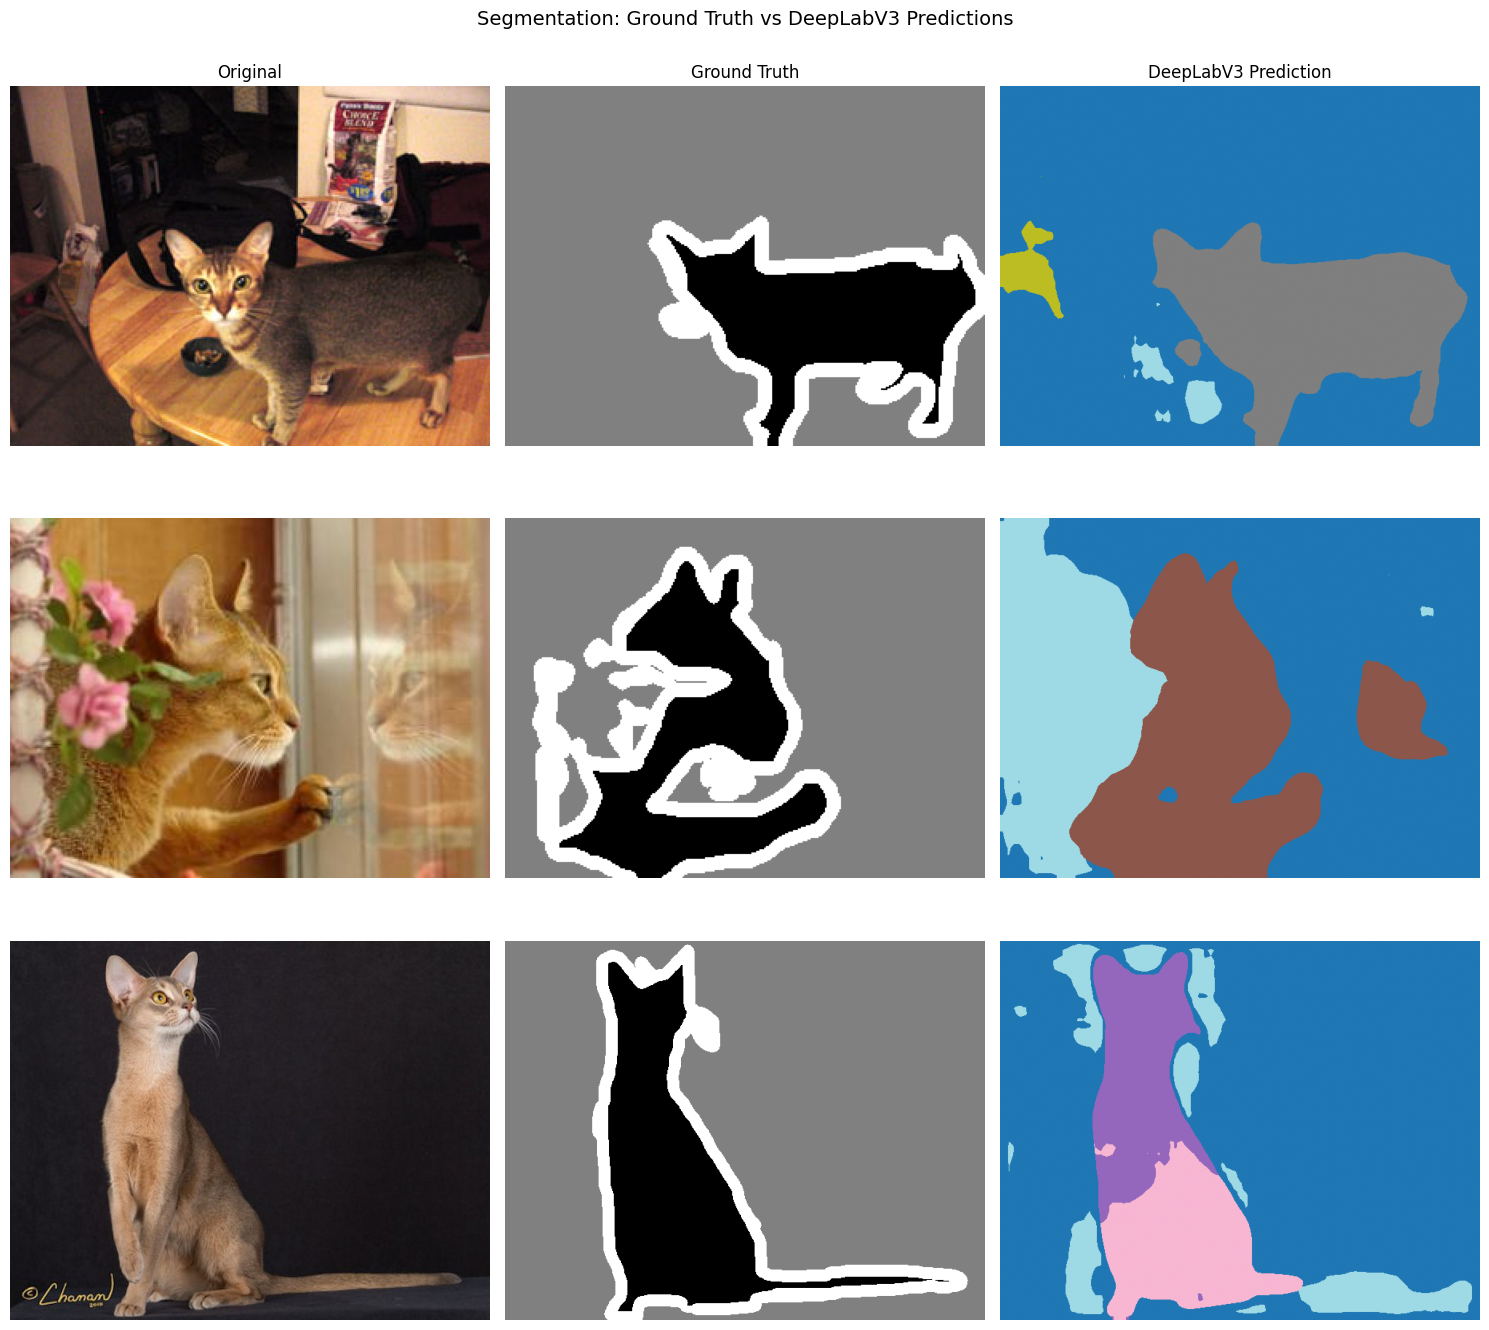

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
sample_indices = [0, 15, 30]

for row, idx in enumerate(sample_indices):
    pet_img, pet_mask = pet_seg[idx]
    pet_mask_arr = np.array(pet_mask)

    # Run DeepLabV3
    inp = preprocess(pet_img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(inp)["out"]
    pred = out.argmax(dim=1).squeeze(0).cpu().numpy()

    # Original
    axes[row, 0].imshow(pet_img)
    axes[row, 0].set_title("Original" if row == 0 else "")
    axes[row, 0].axis("off")

    # Ground truth
    axes[row, 1].imshow(pet_mask_arr, cmap="gray")
    axes[row, 1].set_title("Ground Truth" if row == 0 else "")
    axes[row, 1].axis("off")

    # DeepLabV3 prediction
    axes[row, 2].imshow(pred, cmap="tab20")
    axes[row, 2].set_title("DeepLabV3 Prediction" if row == 0 else "")
    axes[row, 2].axis("off")

plt.suptitle("Segmentation: Ground Truth vs DeepLabV3 Predictions", fontsize=14)
plt.tight_layout()
plt.show()